In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = ""
os.environ["KAGGLE_KEY"] = ""

In [2]:
if not (os.getenv("KAGGLE_USERNAME") and os.getenv("KAGGLE_KEY")):
    print("Please set Kaggle credentials as environment variables.")
else:
    !kaggle datasets download -d paramaggarwal/fashion-product-images-small -p data/
    !unzip data/fashion-product-images-small.zip -d data/

Streaming output truncated to the last 5000 lines.
  inflating: data/myntradataset/images/5813.jpg  
  inflating: data/myntradataset/images/58131.jpg  
  inflating: data/myntradataset/images/58132.jpg  
  inflating: data/myntradataset/images/58133.jpg  
  inflating: data/myntradataset/images/58135.jpg  
  inflating: data/myntradataset/images/58136.jpg  
  inflating: data/myntradataset/images/58137.jpg  
  inflating: data/myntradataset/images/58138.jpg  
  inflating: data/myntradataset/images/58139.jpg  
  inflating: data/myntradataset/images/5814.jpg  
  inflating: data/myntradataset/images/58140.jpg  
  inflating: data/myntradataset/images/58141.jpg  
  inflating: data/myntradataset/images/58143.jpg  
  inflating: data/myntradataset/images/58144.jpg  
  inflating: data/myntradataset/images/58145.jpg  
  inflating: data/myntradataset/images/58146.jpg  
  inflating: data/myntradataset/images/58147.jpg  
  inflating: data/myntradataset/images/58148.jpg  
  inflating: data/myntradataset/i

In [3]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch import nn
from torchvision import models
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

**CustomDataset** Class

In [5]:
class FashionDataset(Dataset):

    def __init__(self, image_folder, transform=None):

        self.image_folder = image_folder
        self.image_files = os.listdir(image_folder)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_folder, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [7]:
dataset = FashionDataset(
    image_folder="/content/data/images",
    transform=transform
)
loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [8]:
model = models.resnet50(pretrained=True)
model

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
model.fc=nn.Identity()
model
emb_model=model.to(device)

emb_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [10]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 79.1 MB/s eta 0:00:00


In [11]:
import faiss

dim=2048
index = faiss.IndexFlatIP(dim)

In [12]:
from tqdm import tqdm


paths=[]

with torch.no_grad():
  for image,path in tqdm(loader):
    image=image.to(device)
    embed=model(image)
    embed = embed.view(embed.size(0), -1)
    embeds = embed.cpu().numpy().astype("float32")
    faiss.normalize_L2(embeds)
    index.add(embeds)
    paths.extend(path)

100%|██████████| 695/695 [02:33<00:00,  4.54it/s]


In [13]:
def SearchImage(img_path,k):
  imgpath=img_path
  img=Image.open(imgpath).convert("RGB")

  img=transform(img).unsqueeze(0).to(device)
  with torch.no_grad():
    emb=model(img)
    emb=emb.view(emb.size(0),-1)
    emb=emb.detach().cpu().numpy().astype("float32")
    faiss.normalize_L2(emb)
  d,i=index.search(emb,k)
  for path in i[0]:
    img=paths[path]
    print(img)
    img=Image.open(img)
    plt.imshow(img)
    plt.show()


/content/data/images/2326.jpg


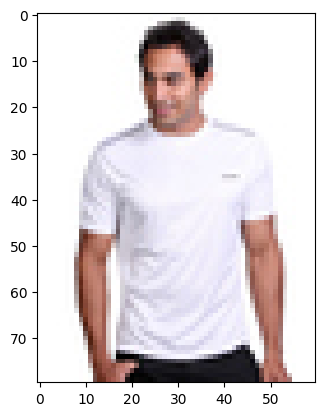

/content/data/images/1616.jpg


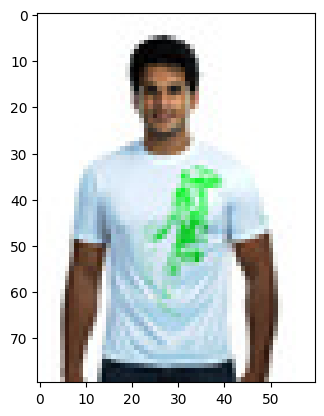

/content/data/images/1891.jpg


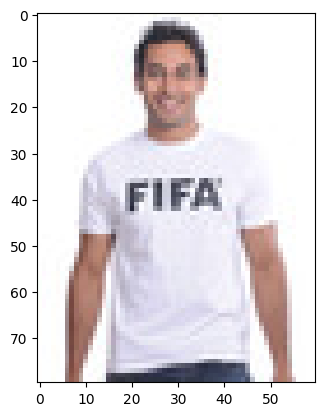

In [15]:
SearchImage("/content/test.png",3)